# Canonical variable candidate check

Select any of the six canonical variables, inspect candidate coverage, apply its plausible-value rule, and draw time-series and ECDF figures.

In [25]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlalchemy as sa
from IPython.display import display

HERE = Path.cwd()
if not (HERE / 'network_var_mapping.py').exists():
    HERE = Path('/workspaces/crmprtd/Quanlity_Control/pipeline/v2_July/variable_mapping_using_all_stations')
sys.path.insert(0, str(HERE))
from network_var_mapping import *

DB_URL = os.getenv(
    'CRMP_DB_URL',
    'postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp'
    '?keepalives=1&keepalives_idle=300&keepalives_interval=300'
    '&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass',
)
engine = sa.create_engine(DB_URL, pool_pre_ping=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Parameters

Change `CANONICAL_VARIABLE` to any value shown in `CANONICAL_VARIABLES`. Use `STATION_OFFSET=0` for the first group, `5` for the next group, and so on.

In [38]:
CANONICAL_VARIABLE = 'air_temperature'
NETWORK_ID = 2
STATION_LIMIT = 5
STATION_OFFSET = 20

print('Available variables:')
print(*CANONICAL_VARIABLES, sep='\n- ')

if CANONICAL_VARIABLE not in CANONICAL_VARIABLES:
    raise ValueError(f'Choose one of: {CANONICAL_VARIABLES}')

Available variables:
air_temperature
- daily_min_temperature
- daily_max_temperature
- precipitation_amount
- snowfall_amount
- snow_depth


## 2. Select stations and load data

In [39]:
# Load the persistent registry directly from CSV.
REGISTRY_PATH = HERE / 'candidate_mappings.csv'
all_candidate_mappings = pd.read_csv(REGISTRY_PATH)
candidate_mappings = all_candidate_mappings[
    all_candidate_mappings['network_id'] == NETWORK_ID
].copy()
if candidate_mappings.empty:
    raise ValueError(
        f'No saved mappings for network {NETWORK_ID} in {REGISTRY_PATH}')

candidate_rows = candidate_mappings[
    candidate_mappings['canonical_variable'] == CANONICAL_VARIABLE
]
if candidate_rows.empty:
    raise ValueError(
        f'No {CANONICAL_VARIABLE} candidates saved for network {NETWORK_ID}'
    )
candidate_ids = candidate_rows['vars_id'].tolist()
display(candidate_rows)

comparison_stations = select_candidate_stations(
    engine, candidate_ids, network_id=NETWORK_ID,
    limit=STATION_LIMIT, offset=STATION_OFFSET
)
if comparison_stations.empty:
    raise ValueError(
        'No stations found. Try a smaller offset or review the candidates.')
comparison_station_ids = comparison_stations['station_id'].tolist()
display(comparison_stations)

candidate_profile = profile_candidate_variables(
    engine, candidate_ids, network_id=NETWORK_ID,
    station_ids=comparison_station_ids
)
candidate_summary = summarize_candidate_profiles(candidate_profile)
display(candidate_summary.round(2))
display(candidate_profile)

,network_id,vars_id,net_var_name,canonical_variable,source_type,daily_aggregation,priority,source_family,mapping_status
0,2,434,CURRENT_AIR_TEMPERATURE1,air_temperature,point,mean,1,network2_auto,needs_review
1,2,436,CURRENT_AIR_TEMPERATURE2,air_temperature,point,mean,2,network2_auto,needs_review
2,2,721,air_temp,air_temperature,point,mean,4,network2_auto,needs_review


,station_id,station_name
0,2712,Great Bear
1,2715,Little Bear
2,2731,Blowdown Peak
3,2732,Blowdown Mid
4,2733,Cayoosh Summit


/tmp/ipykernel_90682/510237115.py:36: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(candidate_summary.round(2))


,vars_id,net_var_name,station_count,total_rows,total_nonnull,first_observation,last_observation,median_station_span_days,median_active_days,median_active_day_pct,median_nonnull_pct
0,434,CURRENT_AIR_TEMPERATURE1,5,1046344,1046344,1985-12-18 17:40:00,2023-03-18 09:00:00,12854.67,8576.0,80.38,100.0
1,436,CURRENT_AIR_TEMPERATURE2,5,288329,288329,1987-10-28 11:00:00,2011-04-05 16:00:00,4502.00,2402.0,68.31,100.0
2,721,air_temp,5,224744,224744,2020-01-08 11:00:00,2026-07-17 15:00:00,2383.17,1959.0,82.20,100.0


,station_id,station_name,vars_id,net_var_name,row_count,nonnull_count,active_days,first_observation,last_observation,observed_min,observed_max,coverage_days,active_day_pct,nonnull_pct
0,2712,Great Bear,434,CURRENT_AIR_TEMPERATURE1,259085,259085,10936,1985-12-18 17:40:00,2023-03-18 09:00:00,-53.50,41.40,13604.638889,80.384346,100.0
1,2712,Great Bear,436,CURRENT_AIR_TEMPERATURE2,24451,24451,1027,1987-10-28 11:00:00,2002-04-03 10:00:00,-30.10,53.00,5271.958333,19.480427,100.0
2,2712,Great Bear,721,air_temp,50338,50338,2171,2020-01-08 11:00:00,2026-07-17 15:00:00,-6416.00,33.30,2383.166667,91.097280,100.0
3,2715,Little Bear,434,CURRENT_AIR_TEMPERATURE1,192273,192273,8164,1998-10-06 17:00:00,2023-03-18 07:00:00,-53.60,33.70,8929.583333,91.426438,100.0
4,2715,Little Bear,436,CURRENT_AIR_TEMPERATURE2,56990,56990,2402,2000-10-19 10:00:00,2008-09-09 15:00:00,-29.00,29.50,2883.208333,83.309970,100.0
5,2715,Little Bear,721,air_temp,44264,44264,1959,2020-01-08 11:00:00,2026-07-17 15:00:00,-34.40,33.70,2383.166667,82.201553,100.0
6,2731,Blowdown Peak,434,CURRENT_AIR_TEMPERATURE1,186928,186928,7968,1988-01-07 15:00:00,2023-03-18 09:00:00,-52.04,99.60,12854.750000,61.984869,100.0
7,2731,Blowdown Peak,436,CURRENT_AIR_TEMPERATURE2,18386,18386,781,2008-02-18 10:00:00,2011-04-05 16:00:00,-2548.00,17.67,1143.250000,68.314017,100.0
8,2731,Blowdown Peak,721,air_temp,40197,40197,1770,2020-01-08 11:00:00,2026-07-17 15:00:00,-3494.00,22.80,2383.166667,74.270928,100.0
9,2732,Blowdown Mid,434,CURRENT_AIR_TEMPERATURE1,205898,205898,8776,1988-01-07 17:00:00,2023-03-18 09:00:00,-34.90,88.30,12854.666667,68.270926,100.0


## 3. Apply the canonical plausible-value rule

In [40]:
observations = fetch_candidate_observations(
    engine, candidate_ids, comparison_station_ids
)
clean_data, qc_summary = apply_canonical_rule(
    observations, CANONICAL_VARIABLE
)
display(qc_summary.round(2))

,station_id,net_var_name,row_count,removed_count,removed_pct
0,2712,CURRENT_AIR_TEMPERATURE1,259085,0,0.00
1,2712,CURRENT_AIR_TEMPERATURE2,24451,0,0.00
2,2712,air_temp,50338,8,0.02
3,2715,CURRENT_AIR_TEMPERATURE1,192273,0,0.00
4,2715,CURRENT_AIR_TEMPERATURE2,56990,0,0.00
5,2715,air_temp,44264,0,0.00
6,2731,CURRENT_AIR_TEMPERATURE1,186928,1,0.00
7,2731,CURRENT_AIR_TEMPERATURE2,18386,11,0.06
8,2731,air_temp,40197,2,0.00
9,2732,CURRENT_AIR_TEMPERATURE1,205898,2,0.00


## 4. Time series

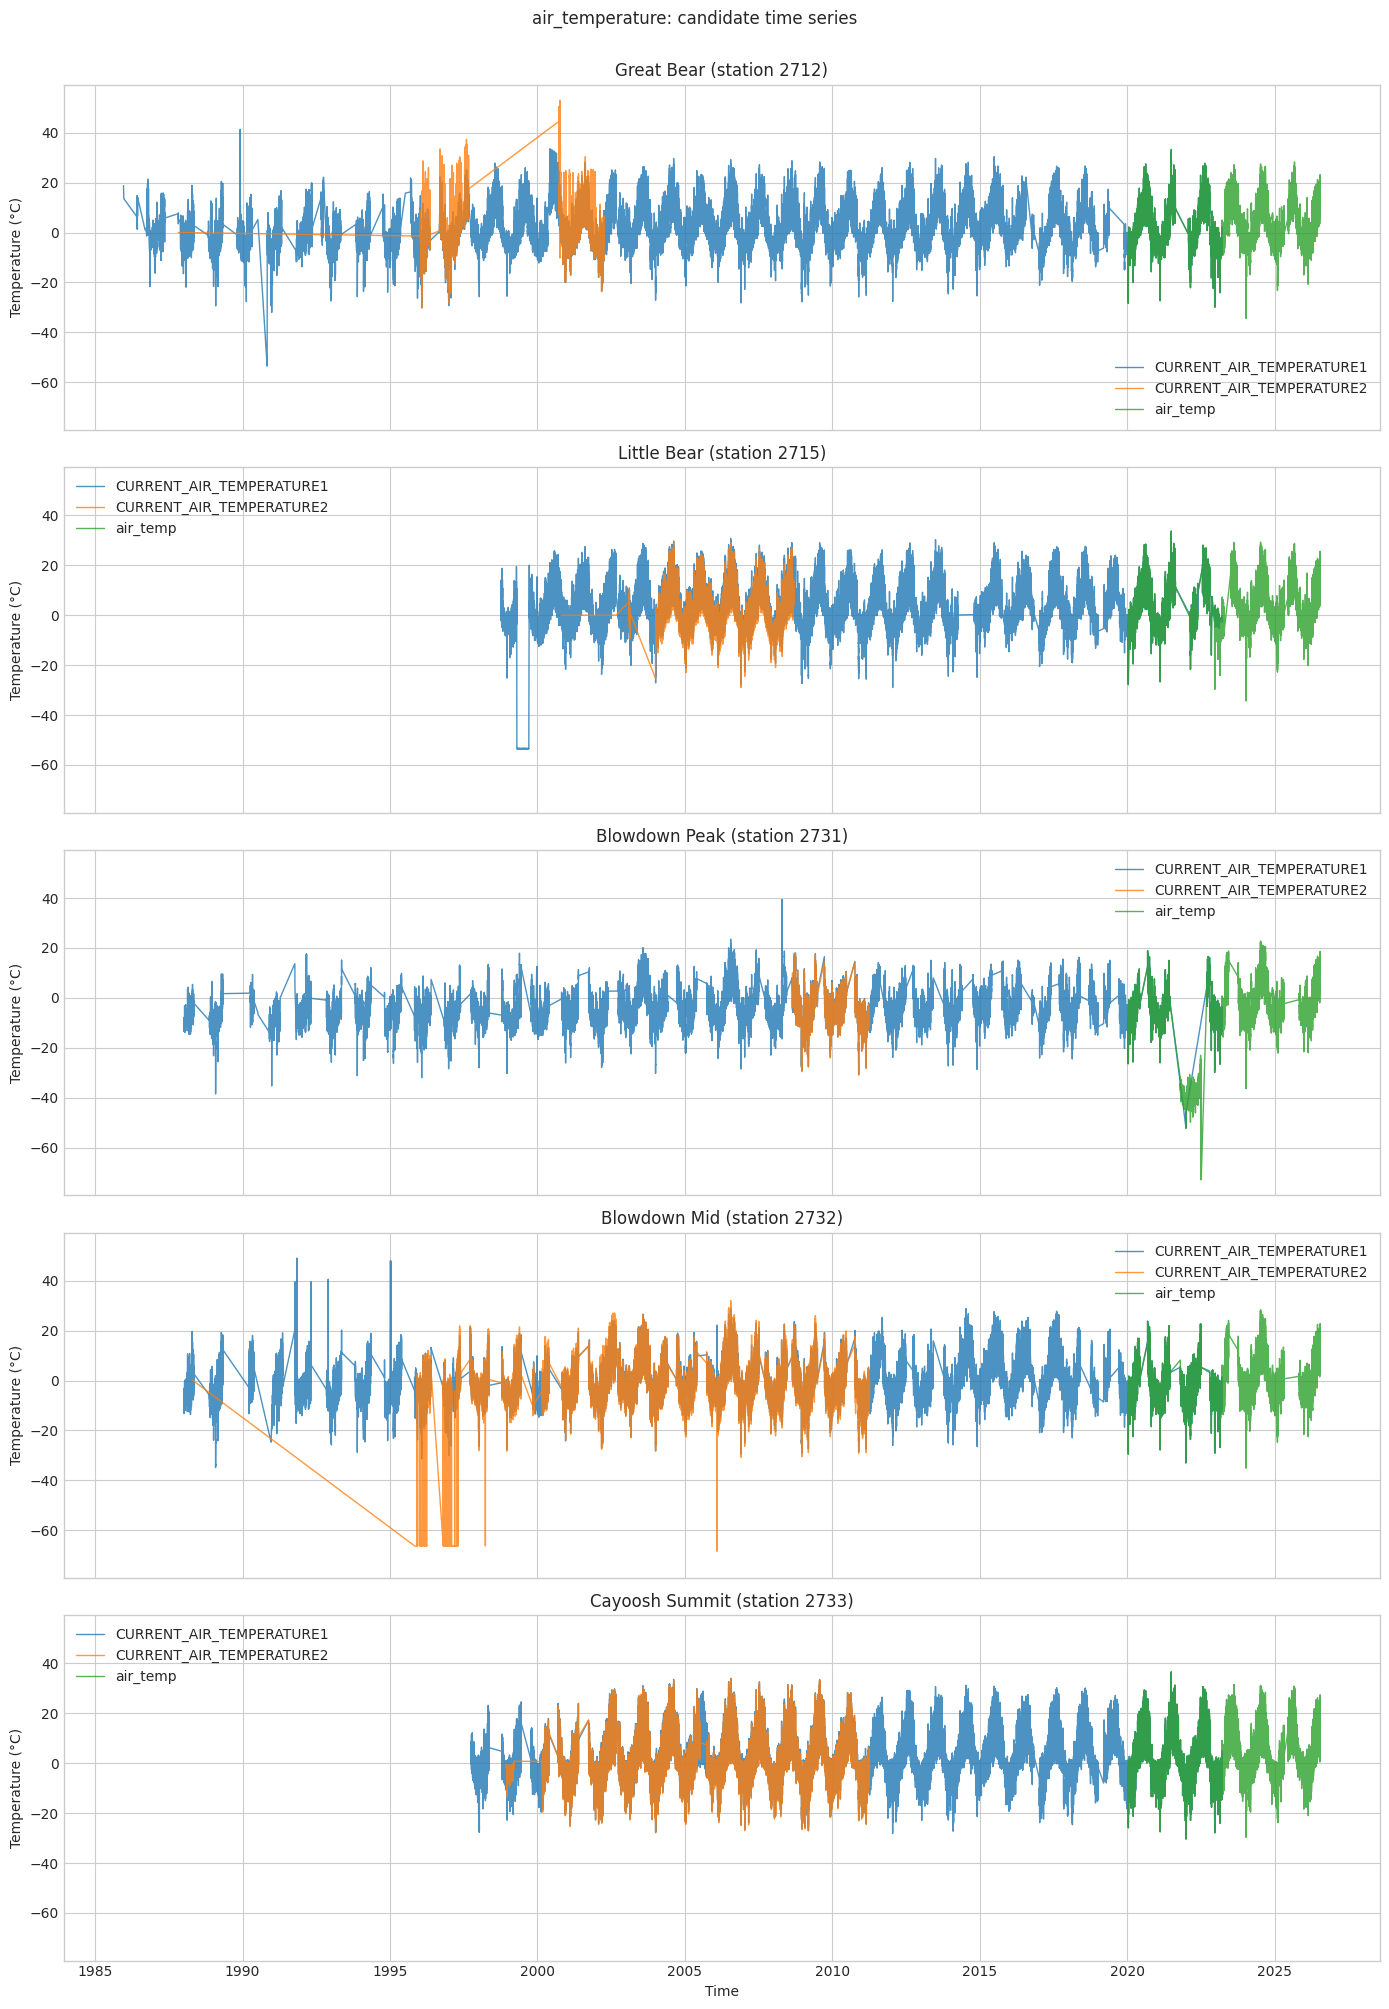

In [41]:
unit_labels = {
    'celsius': 'Temperature (°C)', 'mm': 'Amount (mm)', 'cm': 'Amount (cm)'}
ylabel = unit_labels[CANONICAL_RULES[CANONICAL_VARIABLE].unit]
stations = list(clean_data.groupby('station_id'))

fig, axes = plt.subplots(len(stations), 1, figsize=(14, 4 * len(stations)),
                         sharex=True, sharey=True, squeeze=False)
for ax, (station_id, station_data) in zip(axes.ravel(), stations):
    for variable_name, variable_data in station_data.groupby('net_var_name'):
        ax.plot(variable_data['obs_time'], variable_data['datum'],
                linewidth=1, alpha=0.8, label=variable_name)
    ax.set_title(
        f"{station_data['station_name'].iloc[0]} (station {station_id})")
    ax.set_ylabel(ylabel)
    ax.legend()
axes[-1, 0].set_xlabel('Time')
fig.suptitle(f'{CANONICAL_VARIABLE}: candidate time series', y=1.002)
plt.tight_layout()
plt.show()

## 5. Empirical cumulative distributions

Precipitation and snowfall ECDFs use positive values only and a logarithmic amount axis. Temperature and snow-depth ECDFs retain all plausible values.

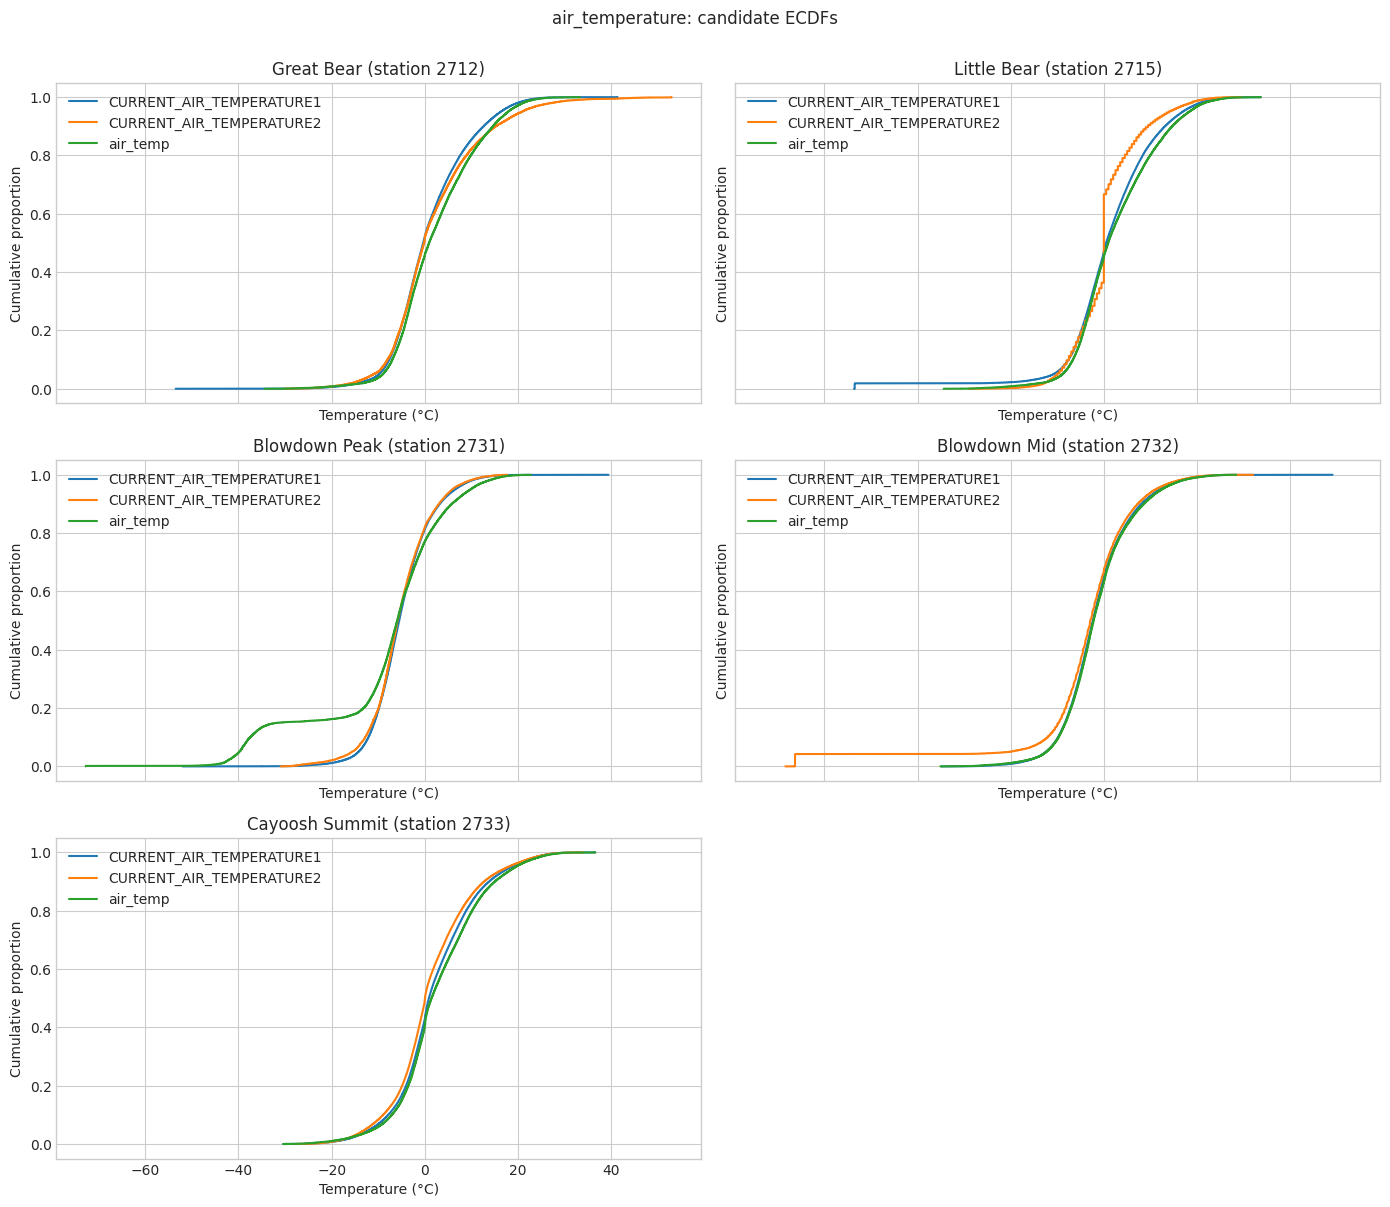

In [42]:
positive_only = CANONICAL_VARIABLE in {
    'precipitation_amount', 'snowfall_amount'}
log_x = positive_only
ncols = 2
nrows = int(np.ceil(len(stations) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                         sharex=True, sharey=True, squeeze=False)
axes = axes.ravel()

for ax, (station_id, station_data) in zip(axes, stations):
    for variable_name, variable_data in station_data.groupby('net_var_name'):
        values = variable_data['datum'].dropna()
        if positive_only:
            values = values[values > 0]
        values = np.sort(values.to_numpy())
        if len(values):
            cumulative = np.arange(1, len(values) + 1) / len(values)
            ax.step(values, cumulative, where='post', label=variable_name)
    if log_x:
        ax.set_xscale('log')
    ax.set_title(
        f"{station_data['station_name'].iloc[0]} (station {station_id})")
    ax.set_xlabel(
        ylabel + (' — positive values, log scale' if positive_only else ''))
    ax.set_ylabel('Cumulative proportion')
    ax.legend()

for ax in axes[len(stations):]:
    ax.set_visible(False)
fig.suptitle(f'{CANONICAL_VARIABLE}: candidate ECDFs', y=1.002)
plt.tight_layout()
plt.show()